# Word Embeddings

## Install dependency

In [ ]:
! pip install spacy

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


## Import required libraries

In [8]:
import spacy
import csv
import os

## Tokenization

In [9]:
class Corpus(object):
    def __init__(self, filename):
        self.filename = filename
        self.nlp = spacy.blank("en")

    def __iter__(self):
        with open(self.filename, "r") as i:
            reader = csv.reader(i, delimiter=",")
            for _, abstract in reader:
                tokens = [t.text.lower() for t in self.nlp(abstract)]
                yield tokens

documents = Corpus("arxiv.csv")

In [10]:
documents = list(documents)
documents[:10]

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


## Embedding

In [11]:
import gensim

In [13]:
model = gensim.models.Word2Vec(documents, min_count=100, window=5, vector_size=100) # created a vector embedding model using the Word2Vec algorithm, with a minimum word count of 100, a context window of 5, and a vector size of 100.

## Using word embeddings

In [ ]:
model.wv["specific"] # retrieved the vector embedding for the word "specific" from the trained Word2Vec model.

array([ 0.35223255, -1.475706  ,  0.63925767,  0.7678384 ,  0.58661884,
       -1.9332821 ,  0.6312213 ,  1.9647683 ,  0.590726  ,  0.22546317,
       -1.2046496 , -0.49265364,  1.4418095 ,  2.4731812 ,  0.71455294,
       -0.34793928, -0.9185273 , -0.04238008,  0.37334168, -0.36414388,
       -1.3040422 , -1.0942411 ,  1.2202746 , -0.9315365 ,  2.1833282 ,
       -0.60609806,  0.81017816,  0.5765929 , -3.5565488 ,  0.5418799 ,
        1.3736955 ,  1.3465637 , -1.9739788 , -1.1449456 , -0.8165254 ,
        0.48442268, -2.1464574 , -0.14376639, -0.9761356 , -0.9558958 ,
        0.36661187,  1.8498616 ,  0.05416257, -1.3151911 , -1.2820076 ,
       -0.62469864, -1.3227437 , -2.2574754 ,  0.16031647, -1.2682333 ,
        0.37258574,  0.702147  ,  0.12216049,  0.4909067 , -0.7518328 ,
       -0.3264888 , -0.00541366, -1.5646577 ,  1.5401987 ,  2.1030855 ,
       -0.69345295,  1.186965  , -0.31918752, -0.17108175, -0.13402537,
       -0.1869017 , -1.81788   , -2.5949438 ,  3.0970285 , -2.74

In [18]:
print(model.wv.similarity("specific", "general")) # calculated the cosine similarity between the vector embeddings of the words "specific" and "general" using the trained Word2Vec model.

0.5144588


In [19]:
print(model.wv.similar_by_word("bert", topn=5)) # retrieved the top 5 most similar words to "bert" based on their vector embeddings in the trained Word2Vec model, and printed the results.

[('roberta', 0.7906507849693298), ('transformer', 0.7671706080436707), ('transformers', 0.7238257527351379), ('elmo', 0.7001283764839172), ('pretrained', 0.6898031234741211)]


In [20]:
print(model.wv.most_similar(positive=["transformer", "lstm"], negative=["bert"], topn=5)) # printed the most similar words to "specific" based on the trained Word2Vec model.

[('rnn', 0.7960827946662903), ('gru', 0.7799249887466431), ('recurrent', 0.747840940952301), ('attentional', 0.7074359655380249), ('bilstm', 0.7006782293319702)]


In [21]:
model.wv.most_similar(positive=["tree"], topn=10) # printed the most similar words to "tree" based on the trained Word2Vec model.

[('trees', 0.7835203409194946),
 ('constituency', 0.7082066535949707),
 ('parse', 0.6916060447692871),
 ('recursive', 0.6800335049629211),
 ('dependency', 0.6615440249443054),
 ('syntax', 0.6232703328132629),
 ('grammar', 0.6110773682594299),
 ('formalism', 0.6077229380607605),
 ('parser', 0.6058385968208313),
 ('grammars', 0.6010549664497375)]

In [23]:
print(model.wv.doesnt_match("lstm cnn gru svm transformer".split())) # identified the word that does not match the others in the list ["lstm", "cnn", "gru", "svm", "transformer"] based on their vector embeddings in the trained Word2Vec model, and printed the result.
print(model.wv.doesnt_match("bert word2vec gpt-2 roberta xlnet".split()))
print(model.wv.doesnt_match("word2vec bert glove fasttext elmo".split()))

svm
word2vec
bert


## Plotting embeddings
To plot embeddings with dimensionality of 100 or more, we need to map them to 2D. Since we could visualize only upto 3D.

In [ ]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

target_word = "bert"
selected_words = [w[0] for w in model.wv.most_similar(positive=[target_word], topn=200)] + [target_word] # selected the top 200 most similar words to "bert" based on their vector embeddings in the trained Word2Vec model, and added "bert" itself to the list of selected words.
embeddings = [model.wv[w] for w in selected_words] + model.wv["bert"]

mapped_embeddings = TSNE(n_components=2, metric='cosine', init='pca').fit_transform(embeddings) # applied t-SNE dimensionality reduction to the vector embeddings of the selected words, using cosine distance as the metric and PCA initialization.

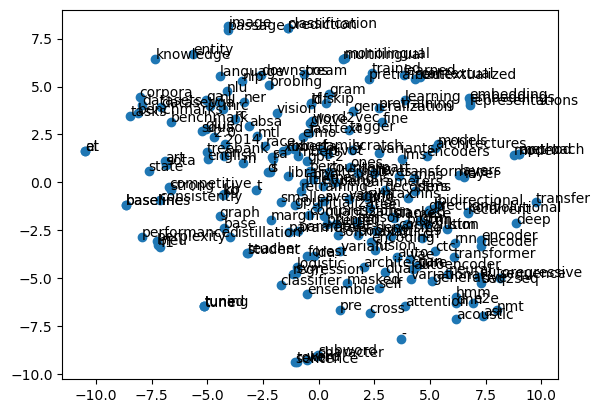

In [28]:
plt.Figure(figsize=(20, 20))
x = mapped_embeddings[:, 0]
y = mapped_embeddings[:, 1]
plt.scatter(x, y)

for i, txt in enumerate(selected_words):
    plt.annotate(txt, (x[i], y[i])) # created a scatter plot of the mapped embeddings, and annotated each point with the corresponding word from the list of selected words.